In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
plt.rcParams["font.family"]="Times New Roman"
plt.rcParams["font.size"]=15
plt.rcParams["axes.labelsize"]=15
plt.rcParams["axes.titlesize"]=15
plt.rcParams["xtick.labelsize"]=15
plt.rcParams["ytick.labelsize"]=15
plt.rcParams["legend.fontsize"]=15

In [27]:
df_xor=pd.DataFrame([[0,0,0],[0,1,1],[1,0,1],[1,1,0]],columns=["Input_01","Input_02","Result"])
df_xor

,Input_01,Input_02,Result
0,0,0,0
1,0,1,1
2,1,0,1
3,1,1,0


In [28]:
w1=w2=0
lr=0.1
b=0
max_iter=20

In [29]:
def step_fun(num):
  if num>=0:
    return 1
  else:
    return 0

In [30]:
def forward_pass(inp,w1,w2,b):
  num=inp.iloc[0]*w1+inp.iloc[1]*w2+b
  return step_fun(num)

In [31]:
def is_true(pred,true):
  return pred==true

In [32]:
def plot_decision_boundary(df_x,df_y,w1,w2,b,epoch):
    plt.figure(figsize=(6,5))
    for i in range(df_x.shape[0]):
        if df_y.iloc[i]==0:
            plt.scatter(df_x.iloc[i,0],
                        df_x.iloc[i,1],
                        color="red",
                        marker="o",
                        s=100)
        else:
            plt.scatter(df_x.iloc[i,0],
                        df_x.iloc[i,1],
                        color="blue",
                        marker="x",
                        s=100)
    if w2!=0:
        x=np.linspace(-0.5,1.5,100)
        y=-(w1*x+b)/w2
        plt.plot(x,y,color="black",label="Decision Boundary")

    elif w1!=0:
        x=-b/w1
        plt.axvline(x,color="black",label="Decision Boundary")

    plt.xlabel("Input_01")
    plt.ylabel("Input_02")
    plt.title("Decision Boundary after Epoch "+str(epoch))
    plt.xlim(-0.5,1.5)
    plt.ylim(-0.5,1.5)
    plt.grid()
    plt.legend()
    plt.savefig(f"plots/xor_epoch_{epoch}.eps")
    plt.show()

In [33]:
def weight_update(w1,w2,b,inp,true,pred):
    error=true-pred
    w1=w1+lr*error*inp.iloc[0]
    w2=w2+lr*error*inp.iloc[1]
    b=b+lr*error
    print("Weights Update occured, new weights are:",w1,w2,"bias:",b)
    return w1,w2,b

In [34]:
def forward_propagation(df_x,df_y,w1,w2,b):
    misclassified_pts=0
    for i in range(df_x.shape[0]):
        inp=df_x.iloc[i]
        pred=forward_pass(inp,w1,w2,b)
        if is_true(pred,df_y.iloc[i])==False:
            w1,w2,b=weight_update(w1,w2,b,inp,df_y.iloc[i],pred)
            misclassified_pts+=1
    return w1,w2,b,misclassified_pts

In [35]:
def epoch_loop(w1,w2,b,df_x,df_y):
    for i in range(max_iter):
        w1,w2,b,misclassified_pts=forward_propagation(df_x,df_y,w1,w2,b)
        print("Weights at the end of epoch",i+1,"are",w1,w2,"and bias is",b,"With misclassified pts are",misclassified_pts)
        plot_decision_boundary(df_x,df_y,w1,w2,b,i+1)
    return w1,w2,b

XOR Gate
Weights Update occured, new weights are: 0.0 0.0 bias: -0.1
Weights Update occured, new weights are: 0.0 0.1 bias: 0.0
Weights Update occured, new weights are: -0.1 0.0 bias: -0.1
Weights at the end of epoch 1 are -0.1 0.0 and bias is -0.1 With misclassified pts are 3


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


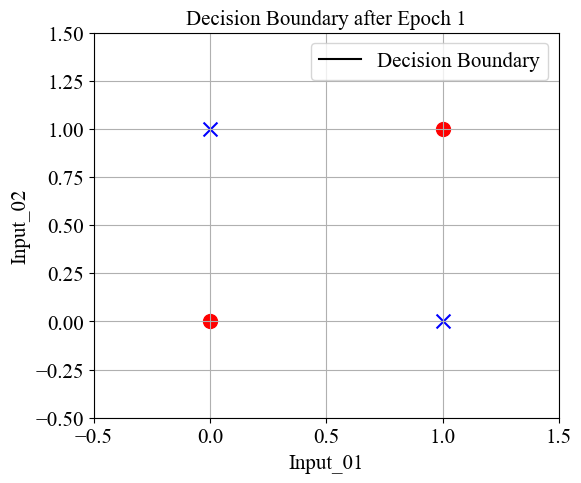

Weights Update occured, new weights are: -0.1 0.1 bias: 0.0
Weights Update occured, new weights are: 0.0 0.1 bias: 0.1
Weights Update occured, new weights are: -0.1 0.0 bias: 0.0
Weights at the end of epoch 2 are -0.1 0.0 and bias is 0.0 With misclassified pts are 3


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


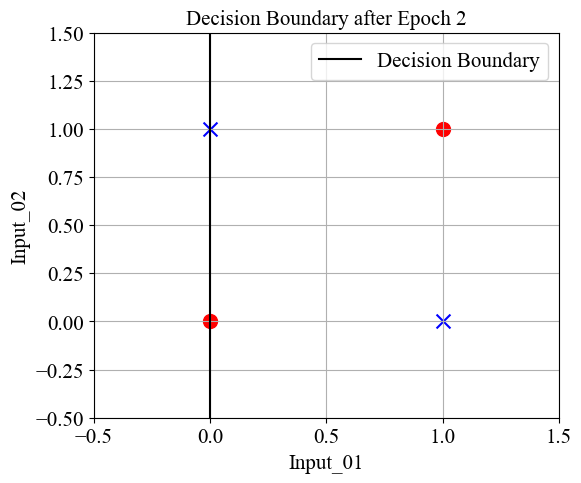

Weights Update occured, new weights are: -0.1 0.0 bias: -0.1
Weights Update occured, new weights are: -0.1 0.1 bias: 0.0
Weights Update occured, new weights are: 0.0 0.1 bias: 0.1
Weights Update occured, new weights are: -0.1 0.0 bias: 0.0
Weights at the end of epoch 3 are -0.1 0.0 and bias is 0.0 With misclassified pts are 4


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


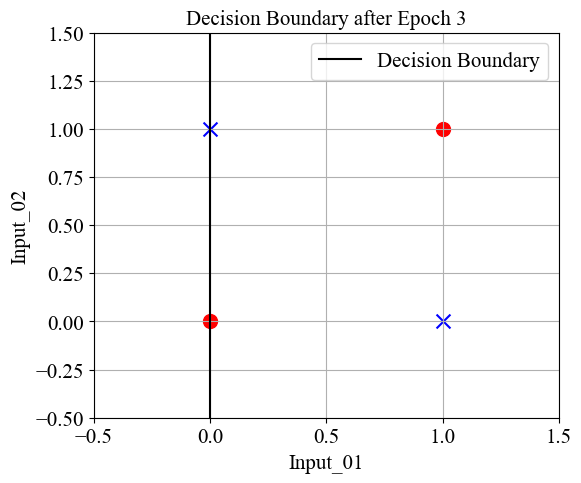

Weights Update occured, new weights are: -0.1 0.0 bias: -0.1
Weights Update occured, new weights are: -0.1 0.1 bias: 0.0
Weights Update occured, new weights are: 0.0 0.1 bias: 0.1
Weights Update occured, new weights are: -0.1 0.0 bias: 0.0
Weights at the end of epoch 4 are -0.1 0.0 and bias is 0.0 With misclassified pts are 4


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


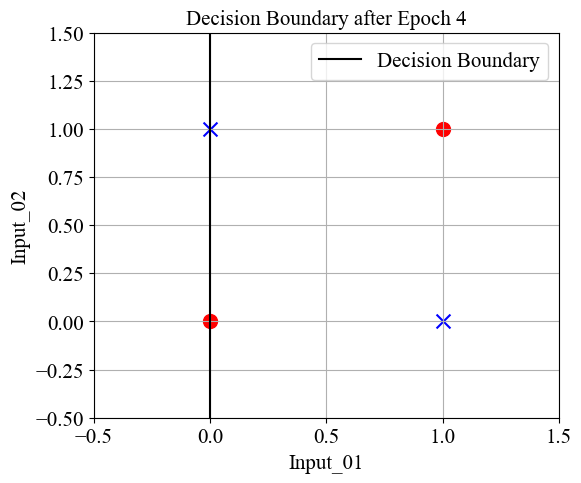

Weights Update occured, new weights are: -0.1 0.0 bias: -0.1
Weights Update occured, new weights are: -0.1 0.1 bias: 0.0
Weights Update occured, new weights are: 0.0 0.1 bias: 0.1
Weights Update occured, new weights are: -0.1 0.0 bias: 0.0
Weights at the end of epoch 5 are -0.1 0.0 and bias is 0.0 With misclassified pts are 4


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


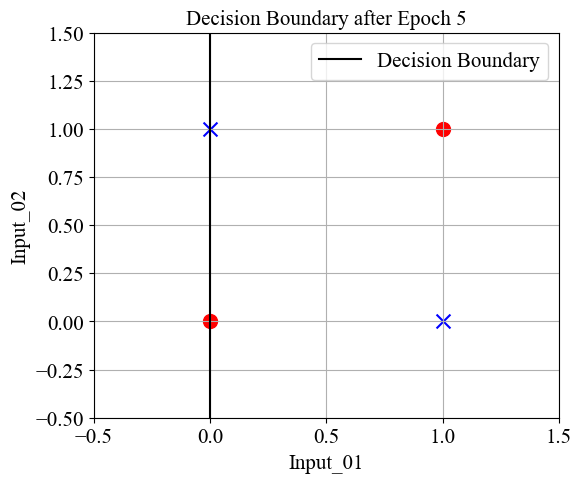

Weights Update occured, new weights are: -0.1 0.0 bias: -0.1
Weights Update occured, new weights are: -0.1 0.1 bias: 0.0
Weights Update occured, new weights are: 0.0 0.1 bias: 0.1
Weights Update occured, new weights are: -0.1 0.0 bias: 0.0
Weights at the end of epoch 6 are -0.1 0.0 and bias is 0.0 With misclassified pts are 4


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


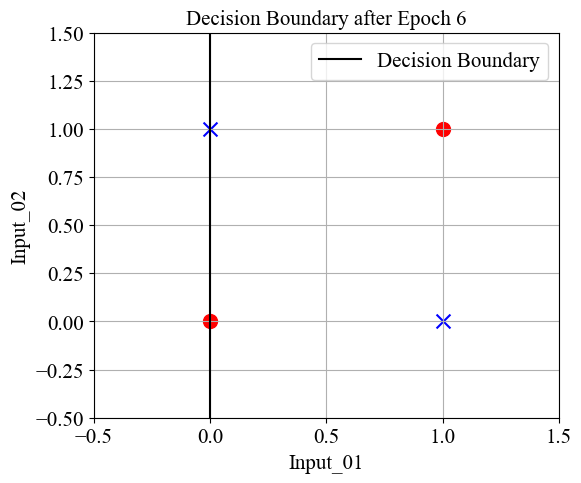

Weights Update occured, new weights are: -0.1 0.0 bias: -0.1
Weights Update occured, new weights are: -0.1 0.1 bias: 0.0
Weights Update occured, new weights are: 0.0 0.1 bias: 0.1
Weights Update occured, new weights are: -0.1 0.0 bias: 0.0
Weights at the end of epoch 7 are -0.1 0.0 and bias is 0.0 With misclassified pts are 4


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


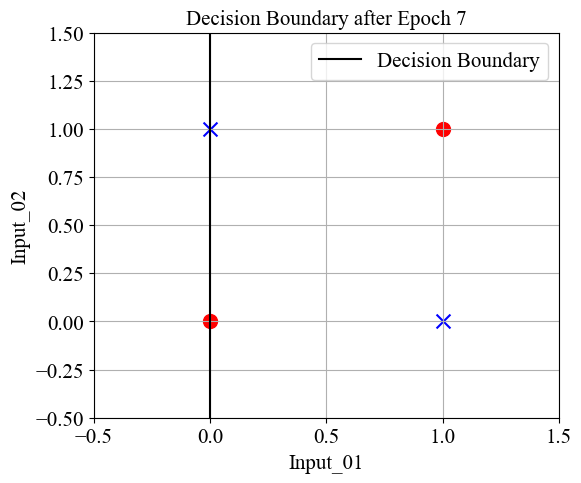

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Weights Update occured, new weights are: -0.1 0.0 bias: -0.1
Weights Update occured, new weights are: -0.1 0.1 bias: 0.0
Weights Update occured, new weights are: 0.0 0.1 bias: 0.1
Weights Update occured, new weights are: -0.1 0.0 bias: 0.0
Weights at the end of epoch 8 are -0.1 0.0 and bias is 0.0 With misclassified pts are 4


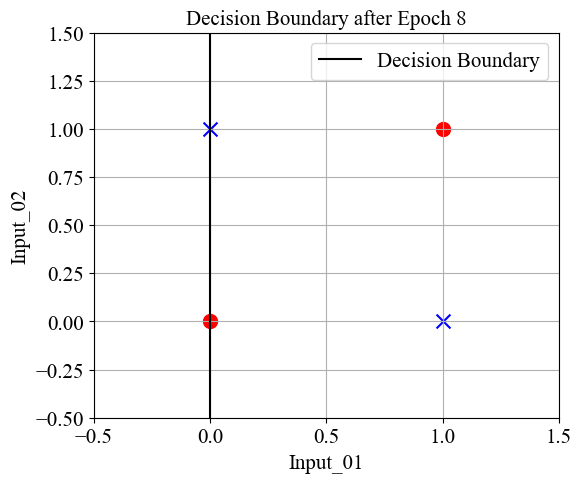

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Weights Update occured, new weights are: -0.1 0.0 bias: -0.1
Weights Update occured, new weights are: -0.1 0.1 bias: 0.0
Weights Update occured, new weights are: 0.0 0.1 bias: 0.1
Weights Update occured, new weights are: -0.1 0.0 bias: 0.0
Weights at the end of epoch 9 are -0.1 0.0 and bias is 0.0 With misclassified pts are 4


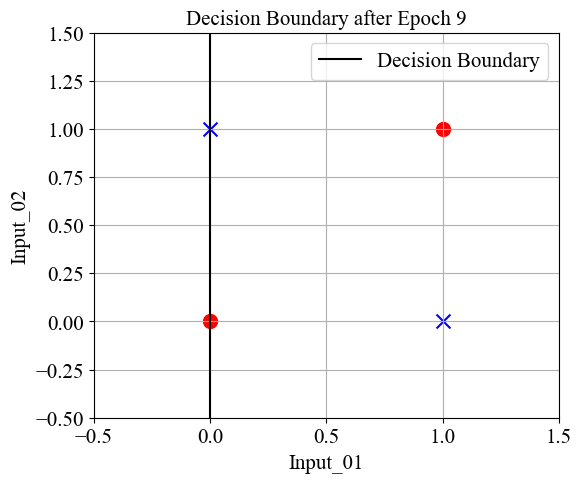

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Weights Update occured, new weights are: -0.1 0.0 bias: -0.1
Weights Update occured, new weights are: -0.1 0.1 bias: 0.0
Weights Update occured, new weights are: 0.0 0.1 bias: 0.1
Weights Update occured, new weights are: -0.1 0.0 bias: 0.0
Weights at the end of epoch 10 are -0.1 0.0 and bias is 0.0 With misclassified pts are 4


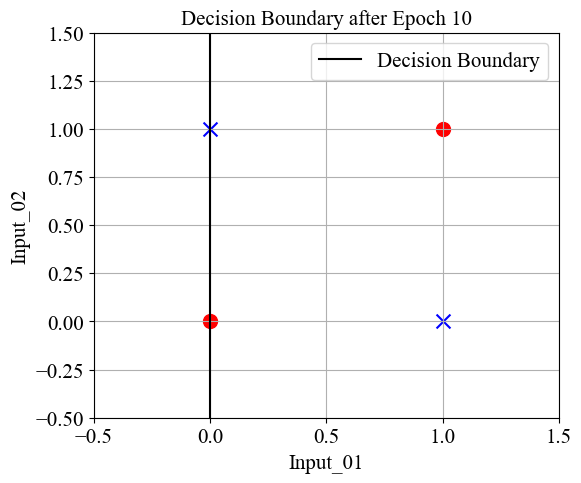

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Weights Update occured, new weights are: -0.1 0.0 bias: -0.1
Weights Update occured, new weights are: -0.1 0.1 bias: 0.0
Weights Update occured, new weights are: 0.0 0.1 bias: 0.1
Weights Update occured, new weights are: -0.1 0.0 bias: 0.0
Weights at the end of epoch 11 are -0.1 0.0 and bias is 0.0 With misclassified pts are 4


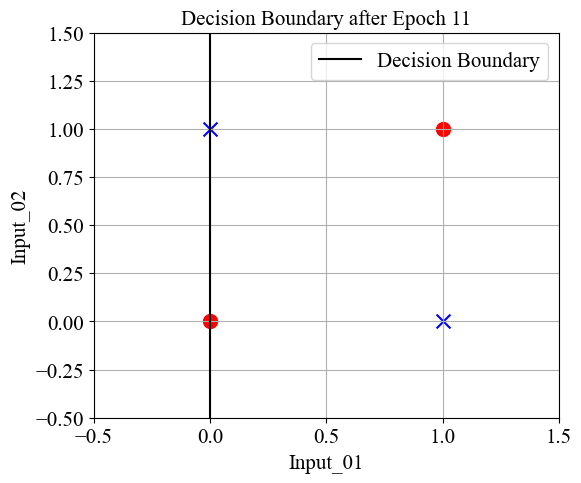

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Weights Update occured, new weights are: -0.1 0.0 bias: -0.1
Weights Update occured, new weights are: -0.1 0.1 bias: 0.0
Weights Update occured, new weights are: 0.0 0.1 bias: 0.1
Weights Update occured, new weights are: -0.1 0.0 bias: 0.0
Weights at the end of epoch 12 are -0.1 0.0 and bias is 0.0 With misclassified pts are 4


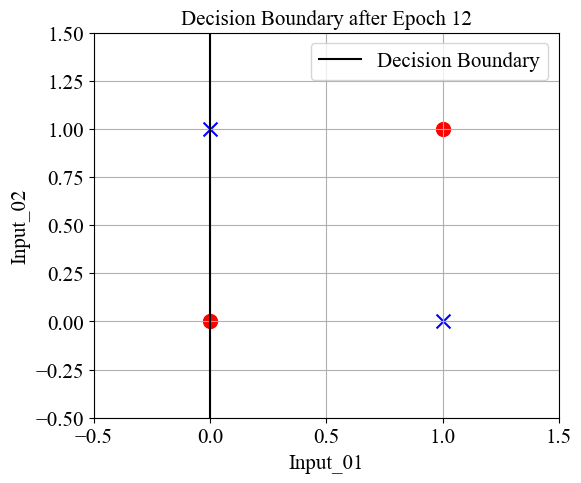

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Weights Update occured, new weights are: -0.1 0.0 bias: -0.1
Weights Update occured, new weights are: -0.1 0.1 bias: 0.0
Weights Update occured, new weights are: 0.0 0.1 bias: 0.1
Weights Update occured, new weights are: -0.1 0.0 bias: 0.0
Weights at the end of epoch 13 are -0.1 0.0 and bias is 0.0 With misclassified pts are 4


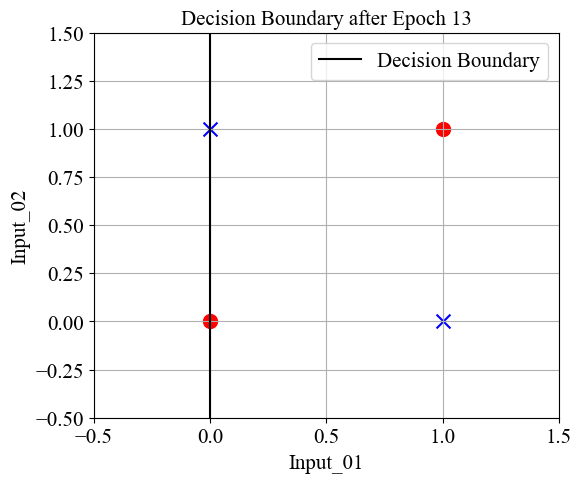

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Weights Update occured, new weights are: -0.1 0.0 bias: -0.1
Weights Update occured, new weights are: -0.1 0.1 bias: 0.0
Weights Update occured, new weights are: 0.0 0.1 bias: 0.1
Weights Update occured, new weights are: -0.1 0.0 bias: 0.0
Weights at the end of epoch 14 are -0.1 0.0 and bias is 0.0 With misclassified pts are 4


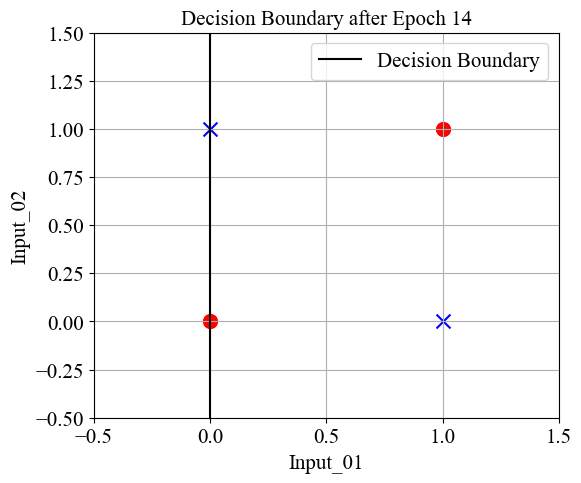

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Weights Update occured, new weights are: -0.1 0.0 bias: -0.1
Weights Update occured, new weights are: -0.1 0.1 bias: 0.0
Weights Update occured, new weights are: 0.0 0.1 bias: 0.1
Weights Update occured, new weights are: -0.1 0.0 bias: 0.0
Weights at the end of epoch 15 are -0.1 0.0 and bias is 0.0 With misclassified pts are 4


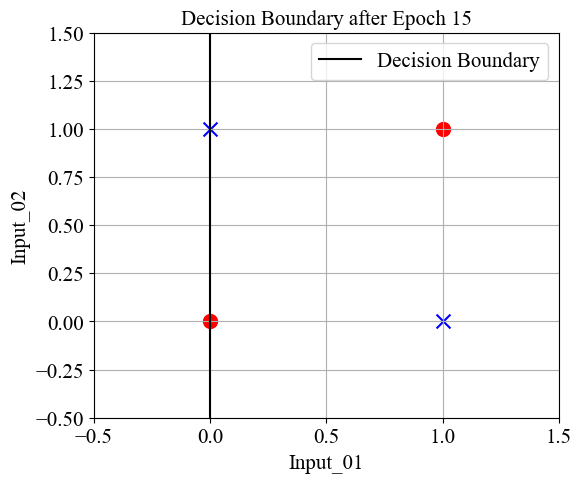

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Weights Update occured, new weights are: -0.1 0.0 bias: -0.1
Weights Update occured, new weights are: -0.1 0.1 bias: 0.0
Weights Update occured, new weights are: 0.0 0.1 bias: 0.1
Weights Update occured, new weights are: -0.1 0.0 bias: 0.0
Weights at the end of epoch 16 are -0.1 0.0 and bias is 0.0 With misclassified pts are 4


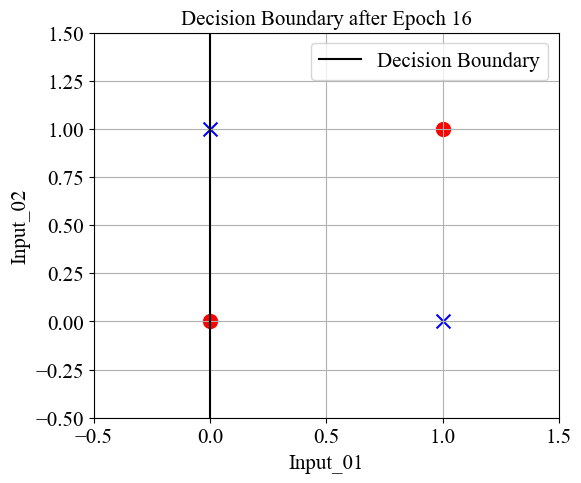

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Weights Update occured, new weights are: -0.1 0.0 bias: -0.1
Weights Update occured, new weights are: -0.1 0.1 bias: 0.0
Weights Update occured, new weights are: 0.0 0.1 bias: 0.1
Weights Update occured, new weights are: -0.1 0.0 bias: 0.0
Weights at the end of epoch 17 are -0.1 0.0 and bias is 0.0 With misclassified pts are 4


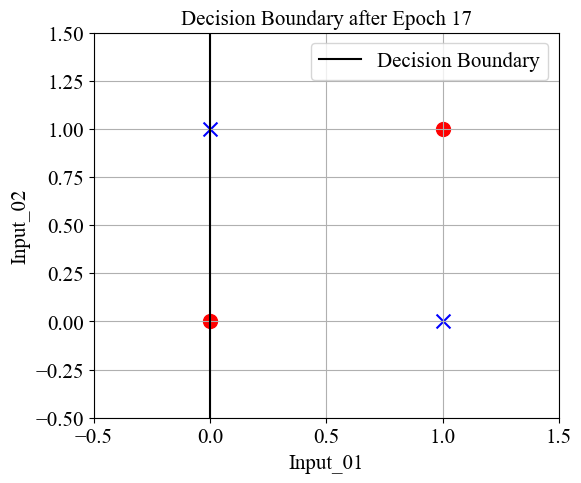

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Weights Update occured, new weights are: -0.1 0.0 bias: -0.1
Weights Update occured, new weights are: -0.1 0.1 bias: 0.0
Weights Update occured, new weights are: 0.0 0.1 bias: 0.1
Weights Update occured, new weights are: -0.1 0.0 bias: 0.0
Weights at the end of epoch 18 are -0.1 0.0 and bias is 0.0 With misclassified pts are 4


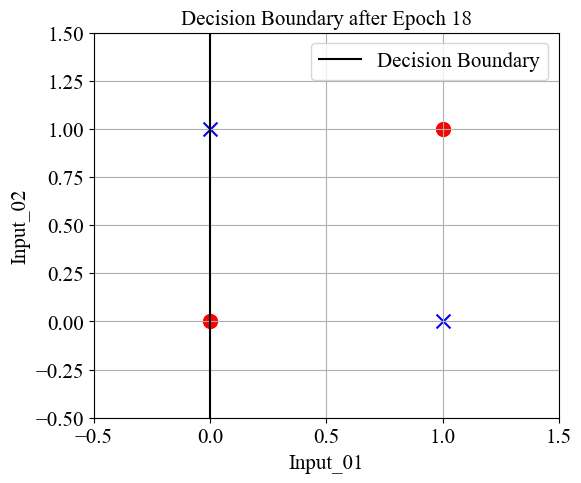

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Weights Update occured, new weights are: -0.1 0.0 bias: -0.1
Weights Update occured, new weights are: -0.1 0.1 bias: 0.0
Weights Update occured, new weights are: 0.0 0.1 bias: 0.1
Weights Update occured, new weights are: -0.1 0.0 bias: 0.0
Weights at the end of epoch 19 are -0.1 0.0 and bias is 0.0 With misclassified pts are 4


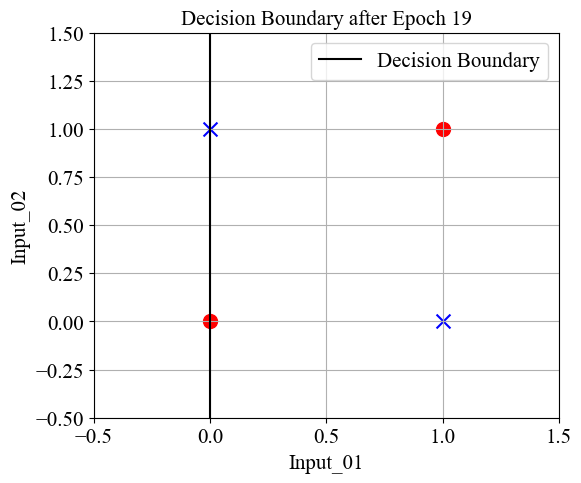

Weights Update occured, new weights are: -0.1 0.0 bias: -0.1
Weights Update occured, new weights are: -0.1 0.1 bias: 0.0
Weights Update occured, new weights are: 0.0 0.1 bias: 0.1
Weights Update occured, new weights are: -0.1 0.0 bias: 0.0
Weights at the end of epoch 20 are -0.1 0.0 and bias is 0.0 With misclassified pts are 4


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


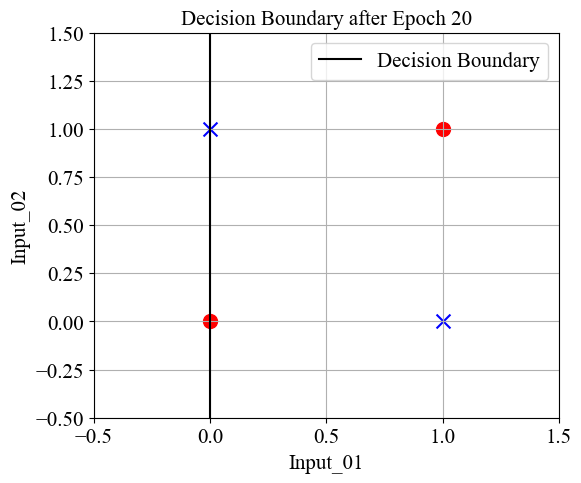

Final weights are: -0.1 0.0 and bias is 0.0


In [36]:
print("XOR Gate")
w1,w2,b=epoch_loop(w1,w2,b,df_xor.iloc[:,0:2],df_xor.iloc[:,2])
print("Final weights are:",w1,w2,"and bias is",b)